In [1]:
!git clone -b gsoc https://github.com/anjaliii255/Genie-Task.git
%cd Genie-Task

Cloning into 'Genie-Task'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 13 (delta 1), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 168.11 KiB | 8.85 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Genie-Task


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import torch
print("PyTorch:", torch.__version__)

!pip install dgl -q
!pip install dglgo -q

PyTorch: 2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.2/77.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 15.2 MB/s eta 0:00:00


In [20]:
!pip install torch-geometric -q

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import h5py
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.10.0+cu128
Device: cuda


In [4]:
file_path = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'

In [5]:
def image_to_pointcloud(image, threshold=0.0):
    # to find non-zero pixels (any channel > threshold)
    mask = np.any(image > threshold, axis=-1)  # (125, 125)
    coords = np.argwhere(mask)  # (N, 2) — row, column indices

    if len(coords) == 0:
        # Edge case: empty image, return single dummy point
        return np.zeros((1, 5), dtype=np.float32)

    # Normalizing
    x = coords[:, 0] / 124.0
    y = coords[:, 1] / 124.0

    # channel values at those coordinates
    ecal   = image[coords[:, 0], coords[:, 1], 0]
    hcal   = image[coords[:, 0], coords[:, 1], 1]
    tracks = image[coords[:, 0], coords[:, 1], 2]

    # Stack into (N, 5): x, y, ecal, hcal, tracks
    point_cloud = np.stack([x, y, ecal, hcal, tracks], axis=1)
    return point_cloud.astype(np.float32)

# Testing
with h5py.File(file_path, 'r') as f:
    sample = f['X_jets'][0]  # (125, 125, 3)

pc = image_to_pointcloud(sample)
print(f"Sample image shape: {sample.shape}")
print(f"Point cloud shape: {pc.shape}")
print(f"Non-zero pixels: {len(pc)}")

Sample image shape: (125, 125, 3)
Point cloud shape: (884, 5)
Non-zero pixels: 884


In [6]:
def pointcloud_to_graph(point_cloud, k=8):
    """
    Converted point cloud to graph using k-nearest neighbors
    Nodes: each non-zero pixel (x, y, ecal, hcal, tracks)
    Edges: connect each node to its k nearest neighbors
    """
    N = len(point_cloud)
    coords = point_cloud[:, :2]  # x, y positions only for distance

    # to compute pairwise distances
    coords_tensor = torch.tensor(coords, dtype=torch.float32)
    diff = coords_tensor.unsqueeze(0) - coords_tensor.unsqueeze(1)  # (N, N, 2)
    dist = torch.sqrt((diff ** 2).sum(-1))  # (N, N)

    # For each node, find k nearest neighbors
    edge_list = []
    _, indices = torch.topk(dist, k=min(k+1, N), dim=1, largest=False)

    for i in range(N):
        for j in indices[i][1:]:  # skip self (index 0)
            edge_list.append([i, j.item()])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()  # (2, E)
    node_features = torch.tensor(point_cloud, dtype=torch.float32)  # (N, 5)

    return node_features, edge_index

# Testing
node_features, edge_index = pointcloud_to_graph(pc, k=8)
print(f"Node features shape: {node_features.shape}")   # (884, 5)
print(f"Edge index shape: {edge_index.shape}")         # (2, num_edges)
print(f"Number of edges: {edge_index.shape[1]}")

Node features shape: torch.Size([884, 5])
Edge index shape: torch.Size([2, 7072])
Number of edges: 7072


In [11]:
print("Loading data into RAM...")

with h5py.File(file_path, 'r') as f:
    X_data = f['X_jets'][:20000]  # (20000, 125, 125, 3)
    y_data = f['y'][:20000]

print(f"Data loaded! Shape: {X_data.shape}")

Loading data into RAM...
Data loaded! Shape: (20000, 125, 125, 3)


In [12]:
class JetGraphDataset(Dataset):
    def __init__(self, X, y, max_nodes=150):
        self.X = X
        self.y = y
        self.max_nodes = max_nodes

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]

        pc = image_to_pointcloud(image)

        if len(pc) > self.max_nodes:
            energy = pc[:, 2] + pc[:, 3] + pc[:, 4]
            top_idx = np.argsort(energy)[-self.max_nodes:]
            pc = pc[top_idx]

        pad_size = self.max_nodes - len(pc)
        if pad_size > 0:
            pc = np.vstack([pc, np.zeros((pad_size, 5), dtype=np.float32)])

        return torch.tensor(pc, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

# Recreate loaders
indices = np.random.permutation(20000)
train_idx = indices[:16000]
val_idx   = indices[16000:]

train_ds = JetGraphDataset(X_data[train_idx], y_data[train_idx])
val_ds   = JetGraphDataset(X_data[val_idx],   y_data[val_idx])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 16000 | Val: 4000


In [13]:
class GNNClassifier(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64):
        super(GNNClassifier, self).__init__()

        self.lin1 = nn.Linear(input_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
        self.lin3 = nn.Linear(hidden_dim, hidden_dim)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # x shape: (batch, max_nodes, 5)
        B, N, _ = x.shape

        # Flatten for BatchNorm
        x = x.view(B * N, -1)

        x = F.relu(self.bn1(self.lin1(x)))
        x = F.relu(self.bn2(self.lin2(x)))
        x = F.relu(self.bn3(self.lin3(x)))

        x = x.view(B, N, -1)  # (B, N, hidden)

        # Global pooling
        mean_pool = x.mean(dim=1)       # (B, hidden)
        max_pool  = x.max(dim=1).values # (B, hidden)
        graph_repr = torch.cat([mean_pool, max_pool], dim=-1)  # (B, hidden*2)

        return self.classifier(graph_repr).squeeze(-1)

model_gnn = GNNClassifier(input_dim=5, hidden_dim=64).to(device)
total_params = sum(p.numel() for p in model_gnn.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 17,409


In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3, weight_decay=1e-4)

def train_epoch(loader):
    model_gnn.train()
    total_loss = 0
    for node_features, labels in loader:
        node_features = node_features.to(device)
        labels = labels.to(device)

        logits = model_gnn(node_features)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def eval_epoch(loader):
    model_gnn.eval()
    all_preds, all_labels = [], []
    total_loss = 0

    with torch.no_grad():
        for node_features, labels in loader:
            node_features = node_features.to(device)
            labels = labels.to(device)

            logits = model_gnn(node_features)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_preds)
    return total_loss / len(loader), auc

In [15]:
# Training
num_epochs = 10
train_losses, val_losses, val_aucs = [], [], []

for epoch in range(num_epochs):
    train_loss = train_epoch(train_loader)
    val_loss, val_auc = eval_epoch(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

print("\nTraining complete!")

Epoch [ 1/10] | Train Loss: 0.6295 | Val Loss: 0.6360 | Val AUC: 0.7373
Epoch [ 2/10] | Train Loss: 0.6065 | Val Loss: 0.6026 | Val AUC: 0.7463
Epoch [ 3/10] | Train Loss: 0.5997 | Val Loss: 0.5995 | Val AUC: 0.7500
Epoch [ 4/10] | Train Loss: 0.5892 | Val Loss: 0.5912 | Val AUC: 0.7594
Epoch [ 5/10] | Train Loss: 0.5887 | Val Loss: 0.5885 | Val AUC: 0.7649
Epoch [ 6/10] | Train Loss: 0.5812 | Val Loss: 0.5846 | Val AUC: 0.7655
Epoch [ 7/10] | Train Loss: 0.5810 | Val Loss: 0.5845 | Val AUC: 0.7675
Epoch [ 8/10] | Train Loss: 0.5772 | Val Loss: 0.5812 | Val AUC: 0.7738
Epoch [ 9/10] | Train Loss: 0.5763 | Val Loss: 0.5810 | Val AUC: 0.7680
Epoch [10/10] | Train Loss: 0.5801 | Val Loss: 0.5827 | Val AUC: 0.7706

Training complete!


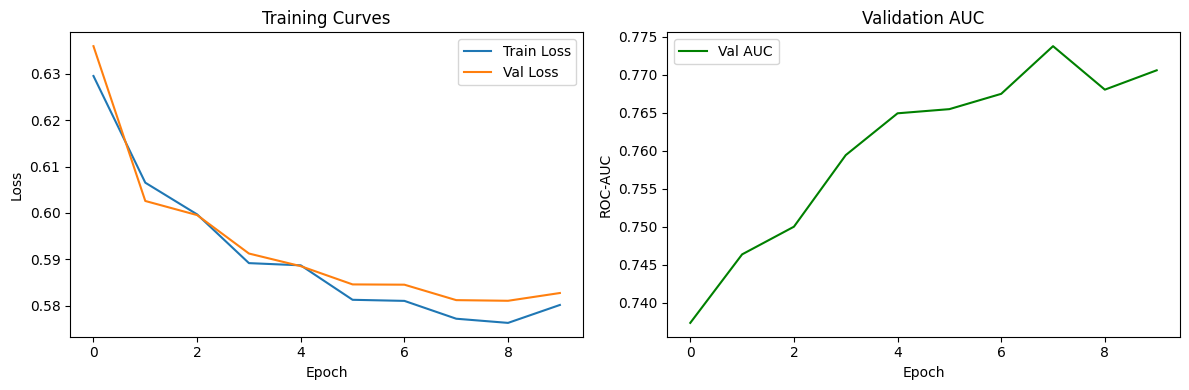

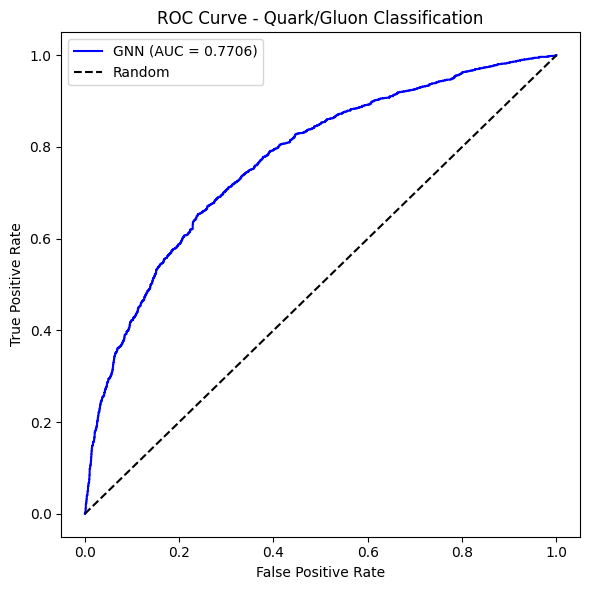

saved!
gnn_roc_curve.png  gnn_training_curves.png  models


In [20]:
import os
os.makedirs('/content/Genie-Task/common_task2_gnn/models', exist_ok=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Curves')
ax1.legend()

ax2.plot(val_aucs, label='Val AUC', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('Validation AUC')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/Genie-Task/common_task2_gnn/gnn_training_curves.png', dpi=150)
plt.show()

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_labels, all_preds)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'GNN (AUC = {auc:.4f})', color='blue')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Quark/Gluon Classification')
plt.legend()
plt.tight_layout()
plt.savefig('/content/Genie-Task/common_task2_gnn/gnn_roc_curve.png', dpi=150)
plt.show()

# Save model
torch.save(model_gnn.state_dict(), '/content/Genie-Task/common_task2_gnn/models/gnn_model.pth')

print("saved!")
!ls /content/Genie-Task/common_task2_gnn/